In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## 1. Generate step-function dataset


In [3]:
torch.manual_seed(0)

N = 100
x = torch.linspace(-2, 2, N).reshape(-1, 1)

# Step function: y = 0 if x < 0, y = 1 if x >= 0
y = (x >= 0).float()

# Smooth grid for plotting
x_plot = torch.linspace(-2.5, 2.5, 100).reshape(-1, 1)
y_true_plot = (x_plot >= 0).float()

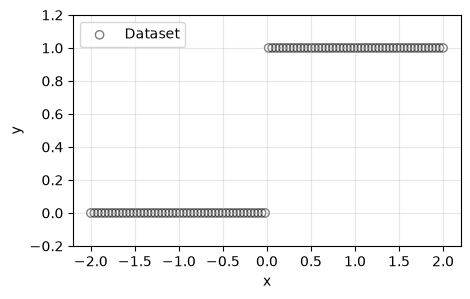

In [4]:
# ============================================================
# Visualization: 1 x 3 subplots
# ============================================================
fig, axes = plt.subplots(1, figsize=(5, 3))


# ------------------------------------------------------------
# 1) Linear regression fails
# ------------------------------------------------------------
ax = axes

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside       
)

# ax.set_title("Linear Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10,loc='upper left')

plt.show()



## 2. Linear regression model


In [5]:
linear_model     = nn.Linear(1, 1)
linear_optimizer = torch.optim.Adam(linear_model.parameters(), lr=0.05)
mse_loss         = nn.MSELoss()

In [6]:
linear_loss_history = []

for step in range(1000):
    y_pred = linear_model(x)
    loss = mse_loss(y_pred, y)

    linear_optimizer.zero_grad()
    loss.backward()
    linear_optimizer.step()

    linear_loss_history.append(loss.item())


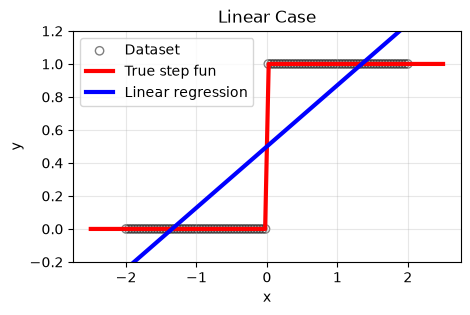

In [9]:
# ============================================================
# Visualization: 1 x 3 subplots
# ============================================================
fig, axes = plt.subplots(1, figsize=(5, 3))



# ============================================================
# Prediction for visualization
# ============================================================
with torch.no_grad():
    y_linear_plot = linear_model(x_plot)




ax = axes

ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside       
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun"
)

ax.plot(
    x_plot.numpy(),
    y_linear_plot.numpy(),
    color="blue",
    linewidth=3,
    label="Linear regression"
)

ax.set_title("Linear Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.show()

## 3. Three-layer MLP model


In [10]:

class ThreeLayerMLP(nn.Module):
    def __init__(self, hidden_dim=64):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)


mlp_model = ThreeLayerMLP(hidden_dim=64)
mlp_model


ThreeLayerMLP(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [11]:
#mlp_optimizer = torch.optim.SGD(mlp_model.parameters(), lr=0.01)
mlp_optimizer = torch.optim.AdamW(mlp_model.parameters(), lr=0.005)
mse_loss      = nn.MSELoss()

mlp_loss_history = []

for step in range(1000):
    logits = mlp_model(x)
    loss   = mse_loss(logits, y)

    mlp_optimizer.zero_grad()
    loss.backward()
    mlp_optimizer.step()

    mlp_loss_history.append(loss.item())
    
    print(f"Step {step+1:04d}: Loss = {loss.item():.4f}")

Step 0001: Loss = 0.3979
Step 0002: Loss = 0.2263
Step 0003: Loss = 0.1172
Step 0004: Loss = 0.0630
Step 0005: Loss = 0.0624
Step 0006: Loss = 0.0904
Step 0007: Loss = 0.1007
Step 0008: Loss = 0.0868
Step 0009: Loss = 0.0634
Step 0010: Loss = 0.0449
Step 0011: Loss = 0.0381
Step 0012: Loss = 0.0409
Step 0013: Loss = 0.0466
Step 0014: Loss = 0.0496
Step 0015: Loss = 0.0476
Step 0016: Loss = 0.0415
Step 0017: Loss = 0.0337
Step 0018: Loss = 0.0270
Step 0019: Loss = 0.0232
Step 0020: Loss = 0.0227
Step 0021: Loss = 0.0245
Step 0022: Loss = 0.0266
Step 0023: Loss = 0.0268
Step 0024: Loss = 0.0249
Step 0025: Loss = 0.0215
Step 0026: Loss = 0.0183
Step 0027: Loss = 0.0164
Step 0028: Loss = 0.0162
Step 0029: Loss = 0.0171
Step 0030: Loss = 0.0181
Step 0031: Loss = 0.0184
Step 0032: Loss = 0.0177
Step 0033: Loss = 0.0164
Step 0034: Loss = 0.0150
Step 0035: Loss = 0.0143
Step 0036: Loss = 0.0143
Step 0037: Loss = 0.0148
Step 0038: Loss = 0.0152
Step 0039: Loss = 0.0151
Step 0040: Loss = 0.0145


In [12]:
# ============================================================
# Prediction for visualization
# ============================================================
with torch.no_grad():
    y_linear_plot   = linear_model(x_plot)
    y_mlp_plot      = mlp_model(x_plot)


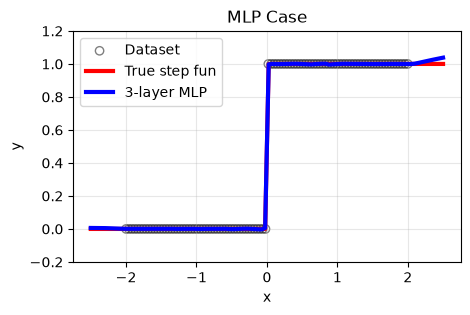

In [13]:
# ============================================================
# Visualization: 1 x 3 subplots
# ============================================================
fig, axes = plt.subplots(1, 1, figsize=(5, 3))


ax = axes
ax.scatter(
    x.numpy(),
    y.numpy(),
    color="black",
    alpha=0.5,
    label="Dataset",
    facecolors="none",   # empty inside    
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun"
)

ax.plot(
    x_plot.numpy(),
    y_mlp_plot.numpy(),
    color="blue",
    linewidth=3,
    label="3-layer MLP"
)

ax.set_title("MLP Case")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

plt.show()


In [14]:
# ============================================================
#  nonlinear features: phi(x) = [x, x^3]
# ============================================================

import torch
import torch.nn as nn

def cubic_feature(x):
    return torch.cat([x, x**3], dim=1)


feature_model    = nn.Linear(2, 1)
feature_optimizer = torch.optim.AdamW(feature_model.parameters(), lr=0.005)
mse_loss          = nn.MSELoss()


In [15]:

feature_loss_history = []

x_feature = cubic_feature(x)

for step in range(1000):
    logits  = feature_model(x_feature)
    loss    = mse_loss(logits, y)

    feature_optimizer.zero_grad()
    loss.backward()
    feature_optimizer.step()

    feature_loss_history.append(loss.item())

    print(f"Step {step+1:04d}: Loss = {loss.item():.4f}")

# ============================================================
# Prediction for visualization
# ============================================================
with torch.no_grad():
    x_plot_feature = cubic_feature(x_plot)
    y_feature_plot = feature_model(x_plot_feature)
    
    


Step 0001: Loss = 2.0197
Step 0002: Loss = 1.9597
Step 0003: Loss = 1.9007
Step 0004: Loss = 1.8426
Step 0005: Loss = 1.7856
Step 0006: Loss = 1.7296
Step 0007: Loss = 1.6746
Step 0008: Loss = 1.6206
Step 0009: Loss = 1.5678
Step 0010: Loss = 1.5159
Step 0011: Loss = 1.4652
Step 0012: Loss = 1.4155
Step 0013: Loss = 1.3669
Step 0014: Loss = 1.3194
Step 0015: Loss = 1.2729
Step 0016: Loss = 1.2276
Step 0017: Loss = 1.1834
Step 0018: Loss = 1.1403
Step 0019: Loss = 1.0983
Step 0020: Loss = 1.0573
Step 0021: Loss = 1.0175
Step 0022: Loss = 0.9788
Step 0023: Loss = 0.9411
Step 0024: Loss = 0.9046
Step 0025: Loss = 0.8691
Step 0026: Loss = 0.8346
Step 0027: Loss = 0.8012
Step 0028: Loss = 0.7689
Step 0029: Loss = 0.7376
Step 0030: Loss = 0.7073
Step 0031: Loss = 0.6780
Step 0032: Loss = 0.6497
Step 0033: Loss = 0.6224
Step 0034: Loss = 0.5960
Step 0035: Loss = 0.5706
Step 0036: Loss = 0.5460
Step 0037: Loss = 0.5224
Step 0038: Loss = 0.4997
Step 0039: Loss = 0.4779
Step 0040: Loss = 0.4569


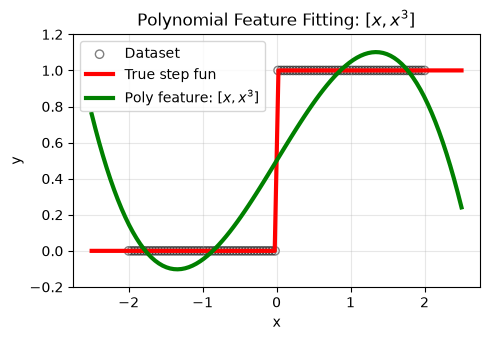

In [16]:
# ============================================================
# 5. Visualization: dataset + polynomial feature fitting
# ============================================================
fig, axes = plt.subplots(1, 1, figsize=(5, 3.5))

# ------------------------------------------------------------
# 1) Polynomial feature fitting
# ------------------------------------------------------------
ax = axes

ax.scatter(
    x.numpy(),
    y.numpy(),
    facecolors="none",
    edgecolors="black",
    alpha=0.5,
    label="Dataset",
)

ax.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    color="red",
    linewidth=3,
    label="True step fun",
)

ax.plot(
    x_plot.numpy(),
    y_feature_plot.numpy(),
    color="green",
    linewidth=3,
    label=r"Poly feature: $[x, x^3]$",
)

ax.set_title(r"Polynomial Feature Fitting: $[x, x^3]$")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-0.2, 1.2)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)


plt.tight_layout()
fig.savefig("reg2-poly-feature.png", dpi=300, bbox_inches="tight")
plt.show()

## loss history visualization

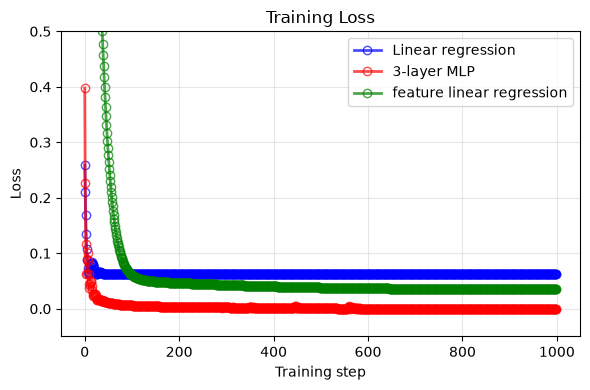

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

# ------------------------------------------------------------
# Training loss
# ------------------------------------------------------------
ax = axes

ax.plot(
    linear_loss_history,
    color="blue",
    linestyle="-", marker="o",    markerfacecolor="none",
    alpha=0.7,
    linewidth=2,
    label="Linear regression",

)

ax.plot(
    mlp_loss_history,
    color="red",
    linestyle="-", marker="o",    markerfacecolor="none",
    alpha=0.7,
    linewidth=2,
    label="3-layer MLP",

)


ax.plot(
    feature_loss_history,
    color="green",
    linestyle="-", marker="o",    markerfacecolor="none",
    alpha=0.7,
    linewidth=2,
    label="feature linear regression",
)

ax.set_title("Training Loss")
ax.set_xlabel("Training step")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

ax.set_ylim(-0.05, .5)
# ------------------------------------------------------------
# Save and show
# ------------------------------------------------------------
plt.tight_layout(w_pad=1)
fig.savefig("reg2-results.png", dpi=300, bbox_inches="tight")
plt.show()